In [ ]:
#PyTorch张量：创建、索引、切片、形状变换（view, reshape).
import torch

#创建张量常用方法
t1=torch.tensor([1,2,3])#从列表或者数组创建张量
#全0,全1张量(两行三列)。eye是单位矩阵。rand生成随机张量[0,1)均匀分布。
t1=torch.zeros(2,3);t1=torch.ones(2,3);t1=torch.eye(3);
t1=torch.arange(0,10,2) #等差数列0 2 4 6 8
t1=torch.rand(2,3);t1=torch.randn(4,5) #Randn均值为0、标准差为1。rand均匀分布,randn标准正态 
x=torch.arange(16).reshape(4,4) #从0-15,4*4数组提取值
#索引,切片
t1=torch.stack([t1+5,t1,t1+2])#变为三维[3,4,5],每个都是t1+数值,共三个
print(f"第一行{x[0]}\n")#x[0,0] x[-1,-1]最后一行最后一列数据
print(f"{x[:4,2:4]}\n{x[:,::2]}")#x[:2]提取第0和第1列 x[:4,2:4] 第0-3行,第2-3列 x[:,::2] x所有行,::2 步长为2 0 2
"""方式1和方式2等价 取指定位置三个元素{(0,1),(1,2),(2,3)}"""
indices=[[0,1,2],[1,2,3]]#方式1
print(f"{x[indices[0],indices[1]]}")
print(x[[0,1,2], [1,2,3]])#方式2
#布尔索引
print(x[x>5])

第一行tensor([0, 1, 2, 3])

tensor([[ 2,  3],
        [ 6,  7],
        [10, 11],
        [14, 15]])
每隔1列取1列
tensor([[ 0,  2],
        [ 4,  6],
        [ 8, 10],
        [12, 14]])
指定位置元素:tensor([ 1,  6, 11])
tensor([ 1,  6, 11])
tensor([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


In [ ]:
import torch
#标量运算
x=torch.tensor([1,2,4,8]);y=torch.tensor([2,2,2,2])
x+y,x-y,x*y,x/y,x**y #x**y==x^y
torch.exp(x) #e^x
#拼接矩阵 cat函数dim=0 按行拼接, dim=1 按列拼接 sum dim=0 按行求和
x=torch.arange(12,dtype=torch.float32).reshape(3,4)
y=torch.tensor([[-1,2.6,4,3],[3,5,2,-3],[8,0,2,3]])
torch.cat((x,y),dim=0),torch.cat((x,y),dim=1)
print(x==y)  #tensor([[False, False, False,  True],[False,  True, False, False],[ True, False, False, False]])
print(x.sum(dim=0))
#内存分配  参数多之后,分配新内存耗费空间。y=x+y:首先计算x+y,为结果分配新的内存,然后使Y指向内存新位置 
before=id(y)
y=y+x
y+=x;y[:]=x+y #y+=x和 z[:] 都可以执行原地操作
print(id(y)==before)
z=torch.zeros_like(y)
print(id(z))
z[:]=x+y
print(id(z))
#转换为其他python对象 .numpy转换为ndarray tensor 再次转换为张量。
A=x.numpy()
B=torch.tensor(A)
type(A),type(B)
a=torch.tensor([3.5])
a,a.item(),float(a),int(a) #item将大小为1的张量转换为Python标量。

tensor([[False, False, False,  True],
        [False,  True, False, False],
        [ True, False, False, False]])
tensor([12., 15., 18., 21.])
False
1245667556352
1245667556352


(tensor([3.5000]), 3.5, 3.5, 3)

In [ ]:
"""torch 形状  x.T 转置"""
import torch
x=torch.arange(12);x=torch.randn(2,3)
x_3x4=x.view(3,-1)#-1表示自动推断维度
x_1x12=x.reshape(-1)#变为1维
print(len(x)) #len x求的是张量长度,即轴的个数
print(x.T.shape)#x的转置的形状 shape==size()  torch.Size([3, 2]) shape[0]取3
print(x.numel())#计算个数 6个
#z=增加/减少维度
x_unsqueeze=x.unsqueeze(0)#在第0维增加1维(1,2,3) 1维(2,1,3)。只加维度
x_squeeze=x_unsqueeze.squeeze(0)#(2,3)
#改变维度顺序
x=torch.randn(2,3,4);x_ord=x.permute(1,0,2)
# x形状(2,3,4)变为x_ord(3,2,4)。
print(f"{x}\n{x_ord}")
"""numpy形状 numpy的形状是4行3列,用shape给出(4,3)。向下是轴0,向右是轴1"""
import numpy as np
A=np.random.randn(4,3)
print(A)
print(A[0],A[1],A[2],A[3])#取每行,4行
print(np.sum(A,axis=0))
print(len(A[0]),A.shape)#len(A[0])是3,len([A])是4

2
torch.Size([3, 2])
6
tensor([[[ 1.9126, -0.3204, -0.6001,  1.0986],
         [-1.2776,  0.8868, -2.1556, -1.4284],
         [ 0.5531, -0.1569,  0.2953,  0.7938]],

        [[ 0.8596,  0.3111,  1.0583, -0.0601],
         [-0.0930,  1.5373, -0.6176,  0.0386],
         [-1.1485, -1.4257,  0.4321,  0.0730]]])
tensor([[[ 1.9126, -0.3204, -0.6001,  1.0986],
         [ 0.8596,  0.3111,  1.0583, -0.0601]],

        [[-1.2776,  0.8868, -2.1556, -1.4284],
         [-0.0930,  1.5373, -0.6176,  0.0386]],

        [[ 0.5531, -0.1569,  0.2953,  0.7938],
         [-1.1485, -1.4257,  0.4321,  0.0730]]])


In [ ]:
"""数据预处理,写入文件"""
import os
os.makedirs(r'D:\ai notebook\data\housemnist', exist_ok=True)
#os.path.join('..','data','house_tiny.csv')
datafile = r'D:\ai notebook\data\housemnist\house_tiny.csv'

with open(datafile,'w') as f:
    f.write('NumRooms,Alley,Price\n')
    f.write('NA,pave,127500\n');f.write('2,NA,106000\n')
    f.write('4,NA,178100\n');f.write('NA,NA,140000\n')
"""填充缺失值。  通过iloc位置索引,data分为两段
    前者为data的前两列,后者为data的最后1列。对于inputs中的缺失值,我们将同一列均值替换NAN项
    dummies进行分类别"""
import pandas as pd
data=pd.read_csv(datafile)
print(data)
inputs,outputs=data.iloc[:,0:2],data.iloc[:,2]
inputs=inputs.fillna(inputs.mean(numeric_only=True))
print(inputs)
inputs = pd.get_dummies(inputs, columns=["Alley"], dummy_na=True)
print(inputs)
"""转换inputs和outputs为张量格式"""
import torch
x,y=torch.tensor(inputs.to_numpy(dtype=float)),torch.tensor(outputs.to_numpy(dtype=float))
print(x,y)

   NumRooms Alley   Price
0       NaN  pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000
   NumRooms Alley
0       3.0  pave
1       2.0   NaN
2       4.0   NaN
3       3.0   NaN
   NumRooms  Alley_pave  Alley_nan
0       3.0        True      False
1       2.0       False       True
2       4.0       False       True
3       3.0       False       True
tensor([[3., 1., 0.],
        [2., 0., 1.],
        [4., 0., 1.],
        [3., 0., 1.]], dtype=torch.float64) tensor([127500., 106000., 178100., 140000.], dtype=torch.float64)


In [ ]:
import torch
"""张量算法的基本性质"""
A=torch.arange(20,dtype=torch.float32).reshape(5,4)
B=A.clone()
print(f"{A}\n{A+B}\n{A*B}")#可以将张量和标量相乘,也不改变矩阵的形状。
x=torch.arange(4,dtype=torch.float32)
#降维:求和,取平均  numel返回的是数组中元素的个数。 shape 0取0维数即行数
print(A.sum(axis=0))
print(A.mean(),A.sum()/A.numel())
print(A.mean(axis=0),A.sum(axis=0)/A.shape[0])
#非降维求和: keepdim 保持轴数不变,即给原来sum的一维数组加一个括号,变为矩阵。  cumsum沿着某个轴做累积总和
sum_A=A.sum(axis=1,keepdim=True)
print(A/sum_A)#可通过广播机制运算
print(A.cumsum(axis=0))
#向量点积
x=torch.tensor([0,1,2,3],dtype=torch.float32);y=torch.ones(4,dtype=torch.float32)
print(x,y,torch.dot(x,y)) #等价于求和print(torch.sum(x*y))

#矩阵与向量的积,矩阵与矩阵的积 这里例子 [5,4] [4,1]。这里的矩阵拆分成5个行向量,为(ai)T。 mv是矩阵*向量,mm是矩阵*矩阵
A=torch.arange(20,dtype=torch.float32).reshape(5,4)
B=torch.ones(size=(4,3),dtype=torch.float32)
x=torch.arange(4,dtype=torch.float32)
print(f"{A}\n{x}\n{torch.mv(A,x)}\n{torch.mm(A,B)}\n{A@B}")#mm只能用于二维张量的乘积。@是通用张量乘积
#范数
u=torch.tensor([3.0,-4.0])
torch.norm(u)#L2范数
torch.abs(u).sum()#L1范数
print(torch.norm(torch.ones(4,9)))#弗罗贝尼乌斯范数像是矩阵的L2范数。


tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]])
tensor([[ 0.,  2.,  4.,  6.],
        [ 8., 10., 12., 14.],
        [16., 18., 20., 22.],
        [24., 26., 28., 30.],
        [32., 34., 36., 38.]])
tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])
tensor([40., 45., 50., 55.])
tensor(9.5000) tensor(9.5000)
tensor([ 8.,  9., 10., 11.]) tensor([ 8.,  9., 10., 11.])
tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  6.,  8., 10.],
        [12., 15., 18., 21.],
        [24., 28., 32., 36.],
        [40., 45., 50., 55.]])
tensor([0., 1., 2., 3.]) tensor([1., 1., 1., 1.]

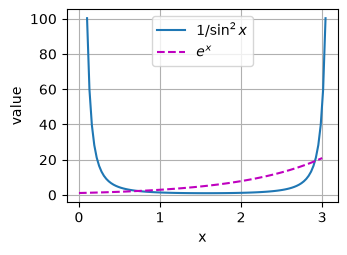

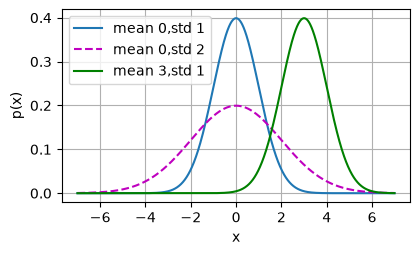

In [2]:
"""用pytorch画函数"""
import numpy as np
import matplotlib.pyplot as plt
import torch
from myutils import use_svg_display, plot_func
use_svg_display()
x=torch.linspace(0.1,torch.pi-0.1,100)
x1=[x,torch.linspace(0,3,100)]
y=1/torch.sin(x)**2
y1=[y,torch.exp(x)]
plot_func(x1,y1, xlabel="x", ylabel="value", legend=[r'$1/\sin^2 x$', r'$e^x$'])
#plot_func(x1,y1, xlabel="x", ylabel="1/sin²x")
plt.show()
"""画标准正态分布图像"""
import torch
import math
from myutils import use_svg_display, plot_func
def normal(x,mu,sigma):
    p=1/torch.sqrt(2*torch.pi*sigma**2)
    return p*torch.exp(-0.5/sigma**2*(x-mu)**2)
x=torch.arange(-7,7,0.01)
params=torch.tensor([[0,1],[0,2],[3,1]])
plot_func(x,[normal(x,mu,sigma) for mu,sigma in params],xlabel='x',ylabel='p(x)',figsize=(4.5,2.5),
          legend=[f"mean {mu},std {sigma}" for mu,sigma in params])

In [ ]:
import torch

#多变量自动求导 对于非标量运算要加sum
x1=torch.tensor([1.0,2.0,3.0],requires_grad=True)
x2=torch.tensor([4.0,2.0,-2.0],requires_grad=True)
y=x1**2+2*x1*x2+x2**3
y.sum().backward()
print(f"2*x1+2*x2:{x1.grad}")#10 8 2
print(f"2*x2+3*x2^2:{x2.grad}")#50 16 18

#梯度累积 每次backward后需要使梯度归0
x=torch.tensor(2.0,requires_grad=True)
y1=x**2;y1.backward()#反向传播相当于计算偏导数
print(x.grad)#4
x.grad.zero_() #用zero后变为12,否则16
y2=x**3;y2.backward()
print(x.grad) #4+12=16

#分离计算 使用detach 会计算z=u*x的导数 u会当成常数
x=torch.arange(4.0,requires_grad=True)
#x.grad.zero_()
y=x*x
u=y.detach()
z=u*x 
z.sum().backward()
print(u.grad,x.grad) #打印 None tensor([0., 1., 4., 9.])
x.grad.zero_()
y.sum().backward()
print(x.grad) #2*x [0.,2.,4.,6.]

#python控制流的梯度计算
def f(a):
    b=a*2
    while b.norm()<1000:#设循环一共执行k次
        b=b*2  #b=a*2*2*...*2=a* 2^(k+1)   K=2^(k+1)，b=Ka。若b.sum()>0-> c=b=ka 若b.sum()≤0 c=100ka
    if b.sum()>0:c=b
    else :c=100*b
    return c
a=torch.randn(size=(),requires_grad=True)
d=f(a)
d.backward()
print(torch.allclose(a.grad, d/a)) # 一般输出True

True


In [ ]:
"""Timer计时类 向量化运算时间远小于矩阵"""
import torch
import time
import math
import numpy as np
#torch.distributions#查找模块中所有的函数和类。
class Timer:
    def __init__(self):
        self.times=[]
        self.start()
    def start(self):#启用计时器
        self.tik=time.time()
    def stop(self):#停止计时器,并将时间记录在列表中。最后返回最后时间
        self.times.append(time.time()-self.tik)
        return self.times[-1]
    def avg(self):#返回平均时间
        return sum(self.times)/len(self.times)
    def sum(self):
        return sum(self.times)
    def cumsum(self):#返回累积时间
        return np.array(self.times).cumsum().tolist()
n=10000
a=torch.ones(n);b=torch.ones(n);c=torch.zeros(n)
timer=Timer()
for i in range(n):
    c[i]=a[i]+b[i]
print(f"{timer.stop():.5f}sec")
timer.start()
d=a+b
print(f"{timer.stop():.5f}sec")

0.13038sec
0.00000sec


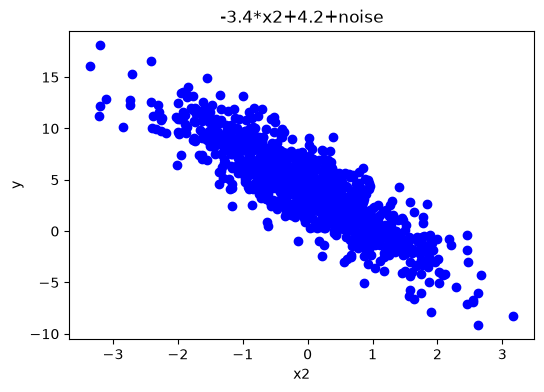

tensor([[-6.0656e-01,  3.6773e-01],
        [ 3.7463e-01,  1.8702e+00],
        [ 1.0123e-01,  1.4286e-01],
        [ 2.3805e+00, -5.0393e-01],
        [ 7.6201e-01,  1.3504e+00],
        [-5.6995e-01,  4.6838e-01],
        [-8.6321e-01,  3.8932e-01],
        [ 4.9235e-01, -3.0704e-01],
        [-8.4375e-01,  1.6629e-01],
        [ 6.0725e-01, -4.3408e-04]]) 
 tensor([[ 1.7510],
        [-1.4114],
        [ 3.9087],
        [10.6622],
        [ 1.1436],
        [ 1.4743],
        [ 1.1455],
        [ 6.2074],
        [ 1.9492],
        [ 5.4134]])
epoch1,loss0.029958
epoch2,loss0.000107
epoch3,loss0.000049


In [ ]:
"""用torch实现线性回归"""
import random
import torch
import matplotlib.pyplot as plt
"""生成数据集:y=Xw+b+噪音。  num_examples 样本个数"""
def synthetic_data(w,b,num_examples):
    X=torch.normal(0,1,(num_examples,len(w))) #x∈R(1000,2)
    y=X@w.view(-1,1)+b+torch.normal(0,0.01,(num_examples,1))
    #y = torch.matmul(X, w) + b #[1000]
    #y += torch.normal(0, 0.01, y.shape) #[1000]
    return X,y.reshape((-1,1)) #reshape保证y固定为列向量(num_examples, 1)
true_w=torch.tensor([2,-3.4]);true_b=4.2 #y=2*x1-3.4*x2+4.2
features,labels=synthetic_data(true_w,true_b,1000)

plt.figure(figsize=(6,4))
plt.scatter(features[:,1],labels,color='blue')
plt.xlabel('x2');plt.ylabel('y');plt.title('-3.4*x2+4.2+noise') 
plt.show()
"""读取数据集   data_iter该函数接受批量大小,特征矩阵和标签向量作为输入,生成大小为batch_size的小批量"""
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples)) #[0,1000),间隔为1
    random.shuffle(indices)#这些样本是随机读取的,没有特定的顺序
# 从0开始，每次跳batch_size步：i=0,10,20,...,990 
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        # 根据索引切片取出这批特征、标签，返回
        yield features[batch_indices],labels[batch_indices] #yield 生成器关键字，函数执行到 yield 暂停，返回数据；
        #下一轮 for 循环再从暂停位置继续执行，节省内存，不用一次性构建全部批次列表
batch_size=10
for X,y in data_iter(batch_size,features,labels):#拿到第一批自理break
    print(X,'\n',y)
    break

w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)
def linreg(X,w,b):#线性回归模型
    return X@w+b
def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2
#定义优化算法 小批量随机梯度下降
def sgd(params,lr,batch_size):
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()
lr=0.03;num_epochs=3;net=linreg;loss=squared_loss
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y) #x和y的小批量损失
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f"epoch{epoch+1},loss{float(train_l.mean()):f}")

torch.Size([100]) torch.Size([100, 1])


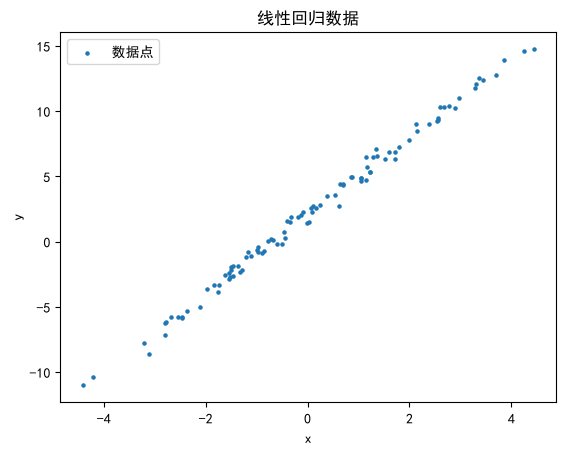

手动回归结果:w=3.0030,b=2.0177


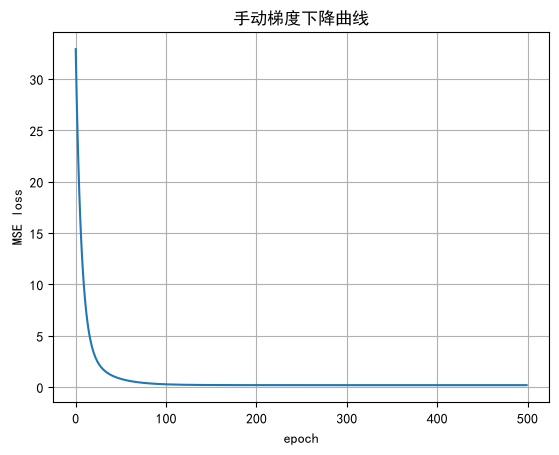

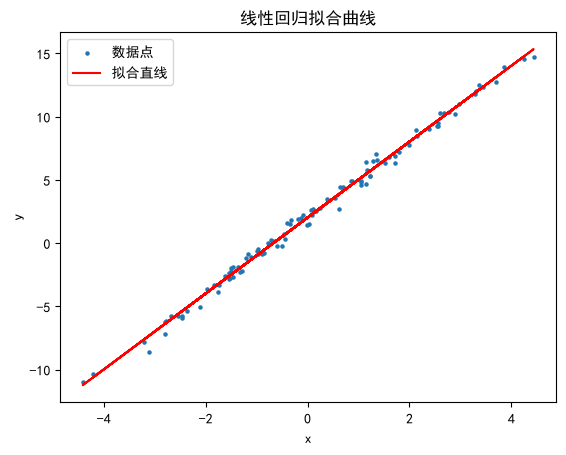

In [18]:
#手写线性回归：定义 w 和 b 张量（不是nn.Linear）。 手动实现：前向传播、手动计算梯度、手动更新参数
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import matplotlib.pyplot as plt
from torch import nn
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示异常
#生成合成数据
torch.manual_seed(42)
X=torch.randn(100,1)*2 #特征(100,1)
true_w=torch.tensor([3.0]);true_b=2.0
y=X@true_w.view(-1,1)+true_b+torch.randn(100,1)*0.5 #加噪音 (100,1)
print((X@true_w).shape,y.shape)  #单纯X@true_w (100,1)*(1,)=(100,) (100,)+randn(100,1)触发广播 (100,100)
#张量如果在计算图上(require_grad=True),它绑定梯度计算。detach用来剥离计算图。 .numpy转换为numpy,matplotlib只为numpy数组和python列表
X_vals=X.detach().numpy();y_vals=y.detach().numpy()
plt.scatter(X_vals,y_vals,s=5,label='数据点')
plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归数据')
plt.legend()
plt.show()
#手写线性回归
w=torch.randn(1,requires_grad=True)#生成一个随机数据
b=torch.randn(1,requires_grad=True)
lr=0.01
epochs=500
losses=[]
for epoch in range(epochs):
    #前向传播
    y_pred=X@w.view(-1,1)+b
    #损失函数
    loss=((y_pred-y)**2).mean()
    losses.append(loss.item())
    loss.backward()#计算梯度
    with torch.no_grad():
        w-=lr*w.grad
        b-=lr*b.grad
    w.grad.zero_()
    b.grad.zero_()
print(f"手动回归结果:w={w.item():.4f},b={b.item():.4f}")
#画损失曲线
plt.plot(range(epochs),losses)
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('手动梯度下降曲线')
plt.grid(True)
plt.show()
#画拟合曲线
y_fit=X*w+b
plt.scatter(X.numpy(),y.numpy(),s=5,label='数据点')
plt.plot(X.numpy(),y_fit.detach().numpy(),'r-',label='拟合直线')
plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归拟合曲线')
plt.legend()
plt.show()

nn.Linear 结果: w = 3.0030, b = 2.0178
真实值: w = 3.0, b = 2.0


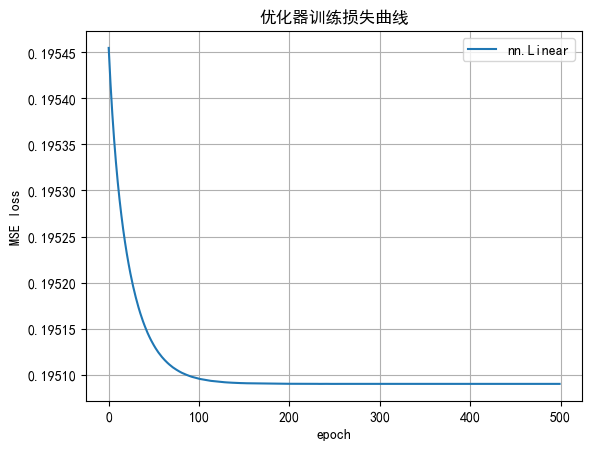

In [ ]:
#使用nn.Linear+优化器
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(42)
X=torch.randn(100,1)*2 #特征(100,1)
true_w=3.0;true_b=2.0
y=true_w*X+true_b+torch.randn(100,1)*0.5
#定义模型
model=nn.Linear(1,1) #输入特征1,输出特征1。即w只有一个值,b只有一个值
with torch.no_grad():
    model.weight.fill_(true_w)# 将权重初始化为真实值 3.0
    model.bias.fill_(true_b) # 将偏置初始化为真实值 2.0
criterion=nn.MSELoss()#均方误差损失
optimizer=optim.SGD(model.parameters(),lr=0.01)#随机梯度下降优化器 model.paraments返回模型所有需要训练的参数
#训练
epochs=500;losses_nn=[]
for epoch in range(epochs):    
    y_pred = model(X)#前向传播:输入X,输出预测值(100,1)
    loss = criterion(y_pred, y)
    losses_nn.append(loss.item())
    # 反向传播
    optimizer.zero_grad()
    loss.backward()#反向传播:计算损失对每个参数的梯度
    optimizer.step()#更新参数 更新 w b
w_nn = model.weight.item()#提取训练后的参数
b_nn = model.bias.item()
print(f"nn.Linear 结果: w = {w_nn:.4f}, b = {b_nn:.4f}")
print(f"真实值: w = {true_w}, b = {true_b}")
plt.plot(range(epochs), losses_nn, label='nn.Linear')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('优化器训练损失曲线')
plt.legend()
plt.grid(True)
plt.show()

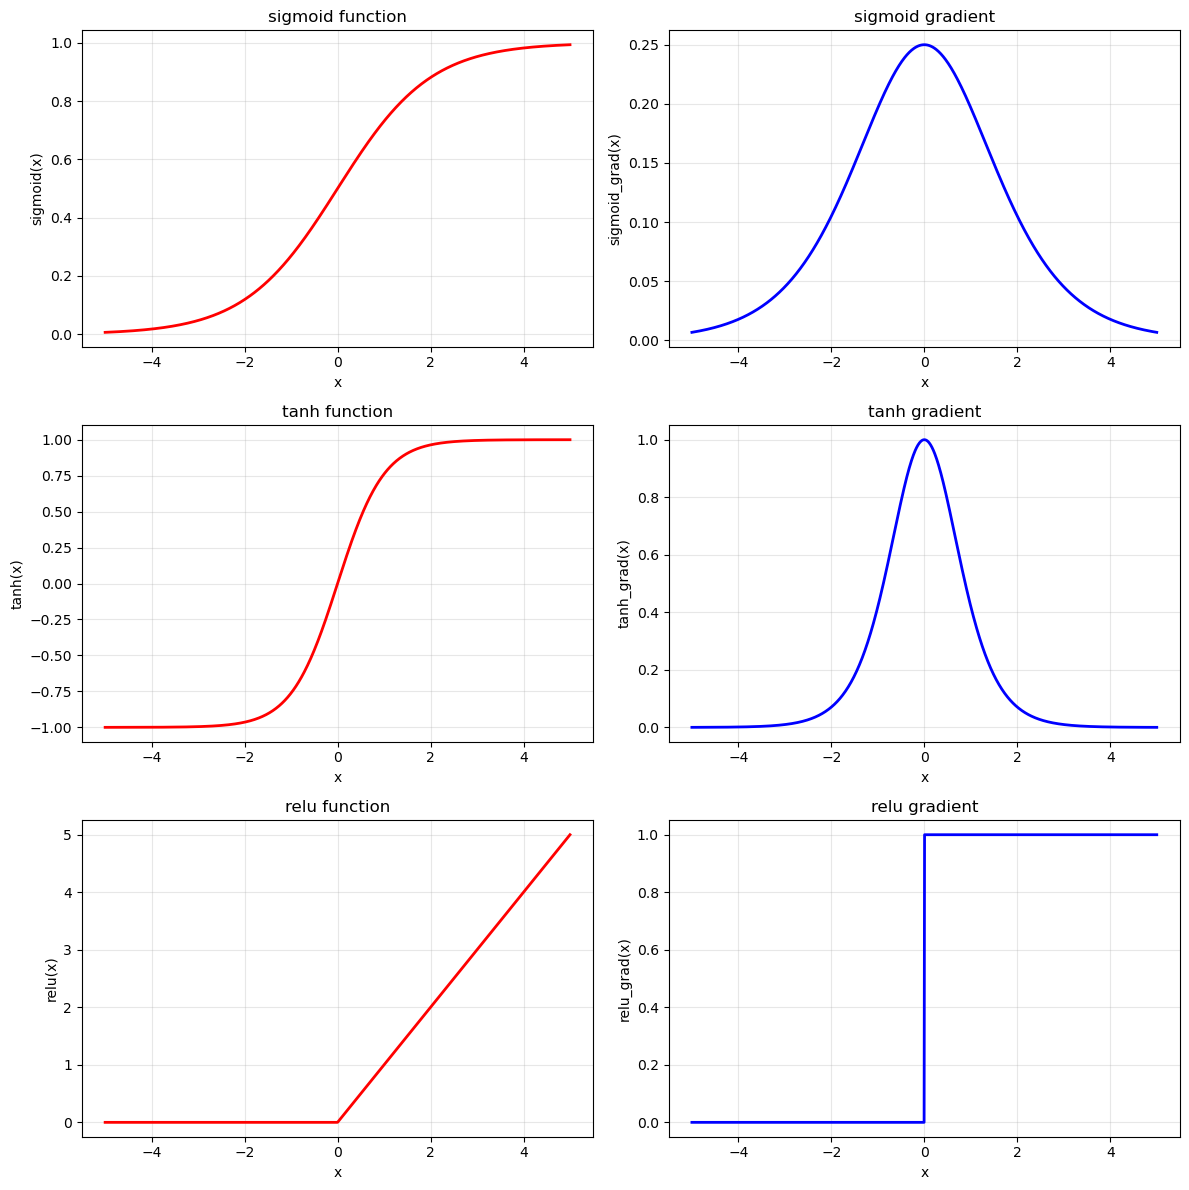

In [1]:
#使用numpy实现sigmoid和tanh,tanh_grad
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import matplotlib.pyplot as plt
X=np.linspace(-5,5,1000)
def sigmoid(x):
    return 1/(1+np.exp(-x))
def sigmoid_grad(x):
    return np.exp(-x)/((1+np.exp(-x))**2)
def tanh(x):
    a=np.exp(x);b=np.exp(-x)
    return (a-b)/(a+b)
def tanh_grad(x):
    return 1-tanh(x)**2
def relu(x):
    return np.maximum(x,0)
def relu_grad(x):
    return (x>0).astype(float)
plt.figure(figsize=(12,12))
funcs=[sigmoid,tanh,relu]
funcs_grad=[sigmoid_grad,tanh_grad,relu_grad]
strc=['sigmoid','tanh','relu']
for i in range(3):
    plt.subplot(3,2,i*2+1)
    plt.plot(X,funcs[i](X),'r-',linewidth=2)
    plt.xlabel('x')
    plt.ylabel(f'{strc[i]}(x)')
    plt.title(f'{strc[i]} function')
    plt.grid(True,alpha=0.3)
    plt.subplot(3,2,i*2+2)
    plt.plot(X,funcs_grad[i](X),'b-',linewidth=2)
    plt.xlabel('x')
    plt.ylabel(f'{strc[i]}_grad(x)')
    plt.title(f'{strc[i]} gradient')
    plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

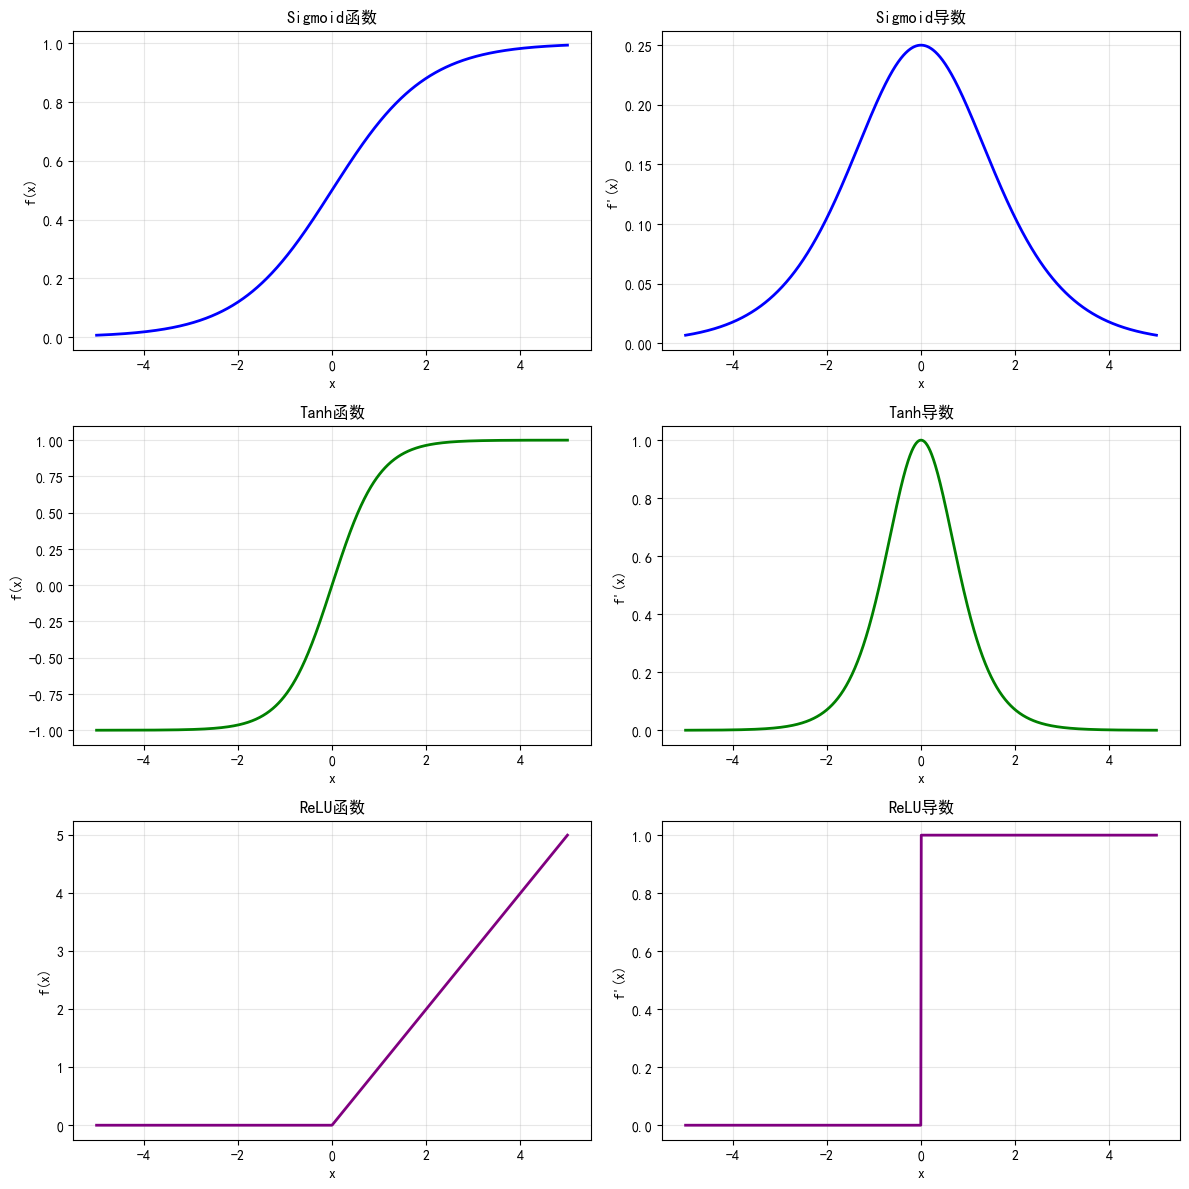

In [15]:
#用torch实现激活函数
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体
plt.rcParams['axes.unicode_minus'] = False          # 解决负号显示异常
def sigmoid(x):
    return 1/(1+torch.exp(-x))
def tanh(x):
    return torch.tanh(x)
def relu(x):
    return torch.maximum(x,torch.zeros_like(x))#输入张量形状相同且所有元素值为 0 的新张量。为了防止广播
#生成x并开启梯度
x=torch.linspace(-5,5,1000,requires_grad=True)
funcs=[sigmoid,tanh,relu]
names=['Sigmoid','Tanh','ReLU']
colors=['blue','green','purple']
plt.figure(figsize=(12,12))
for i,(func,name,colo) in enumerate(zip(funcs,names,colors)):
    y=func(x)
    #反向传播求导
    y.sum().backward(retain_graph=True)
    grad=x.grad.clone()
    x.grad.zero_()
    #转为nnumpy
    x_np=x.detach().numpy()
    y_np=y.detach().numpy()
    grad_np=grad.detach().numpy()
    #左图:函数
    plt.subplot(3,2,i*2+1)
    plt.plot(x_np,y_np,color=colo,linewidth=2)
    plt.title(f'{name}函数')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True,alpha=0.3)
    #右图导数
    plt.subplot(3,2,i*2+2)
    plt.plot(x_np,grad_np,color=colo,linewidth=2)
    plt.title(f'{name}导数')
    plt.xlabel('x')
    plt.ylabel("f'(x)")
    plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import torch
A=torch.arange(20,dtype=torch.float32).reshape(5,4)
B=A.clone()
A+B,A*B#点乘,元素相乘，这种方式只有在最后一行才打印
B=torch.ones(4,3)
print(A,B)
torch.mm(A,B)#A * B 矩阵乘积
u=torch.tensor([3.0,-4.0])
torch.norm(u)#第二范式 sqrt(3^2+(-4.0)^2)
print(torch.sqrt(sum(u**2)))#第二范式
print(torch.abs(u).sum())#第一范式
torch.norm(torch.ones((4,9)))#弗罗贝尼乌斯范数
           

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.],
        [12., 13., 14., 15.],
        [16., 17., 18., 19.]]) tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
tensor(5.)
tensor(7.)
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])


In [21]:
import numpy as np
import torch
def f(x):
    return 3*x**2-4*x
def numerical_lim(f,x,h):
    return (f(x+h)-f(x))/h
h=0.1
for i in range(5):
    print(f'h={h:.5f},numerical_lim={numerical_lim(f,1,h):.5f}')
    h*=0.1

h=0.10000,numerical_lim=2.30000
h=0.01000,numerical_lim=2.03000
h=0.00100,numerical_lim=2.00300
h=0.00010,numerical_lim=2.00030
h=0.00001,numerical_lim=2.00003


In [ ]:
"""
    Focal Loss:计算交叉熵损失
"""
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):#y=2.a=0.25
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: (batch, C)  logits
        # targets: (batch,) 类别索引

        # 1. 计算概率
        p = torch.sigmoid(inputs)  # 二分类
        
        # 2. 计算 p_t
        # 对于正样本（target=1）：p_t = p
        # 对于负样本（target=0）：p_t = 1-p
        p_t = p * targets + (1 - p) * (1 - targets) #target=1 pt=p.target=0 pt=1-p
        
        # 3. 计算调制因子 (1 - p_t)^gamma
        modulating_factor = (1 - p_t) ** self.gamma
        
        # 4. 计算 alpha_t target=1:at=a,target=0:at=1-a
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        
        # 5. 计算 Focal Loss
        loss = -alpha_t * modulating_factor * torch.log(p_t + 1e-8)
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss
        #reduction聚合,可以选择均值,直接求和,返回每个样本单独损失。

In [1]:
""" dtype=float,显示定义为float。
    np.arange 默认起始为0,步长为1.np.array定义数组。reshape重组数组。array直接定义数组 """
import numpy as np
a1=np.arange(2,10,1.5) #[2,10)  [2.  3.5 5.  6.5 8.  9.5]
arr1=np.arange(10,0,-2,dtype=float) #[10.  8.  6.  4.  2.]
a2=np.linspace(0,11,13)

a2=np.arange(12).reshape(4,1,3) #[[[ 0  1  2]] [[ 3  4  5]] [[ 6  7  8]] [[ 9 10 11]]]
a2=a2.reshape(3,-1) #-1 自动计算元素
print(a2.shape) #三维(4, 1, 3) 二维(3,4) 一维(12,)

arr1=np.array([[1,2,3],[4,5,6]])

(3, 4)
